# Services Sector vs Unemployment Analysis

This notebook provides an in-depth analysis of the relationship between Services Sector and Unemployment in Sri Lanka, matching the comprehensive exploratory and statistical depth seen in other macro-labour combinations.

## 1. Data Loading & Initial Exploration

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')

# Load main unemployment data (1991-2023)
unemp_df = pd.read_csv('../labour/csv/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.csv', skiprows=4)
unemp_sl = unemp_df[unemp_df['Country Name'] == 'Sri Lanka'].copy()
years = [str(y) for y in range(1991, 2024)]
unemp_sl = unemp_sl[['Country Name'] + years].melt(id_vars=['Country Name'], var_name='Year', value_name='Unemployment_Rate')
unemp_sl['Year'] = pd.to_datetime(unemp_sl['Year'], format='%Y')
unemp_sl.set_index('Year', inplace=True)
unemp_sl.drop(columns=['Country Name'], inplace=True)

print("Unemployment Data Info:")
print(unemp_sl.info())
unemp_sl.head()

Unemployment Data Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 33 entries, 1991-01-01 to 2023-01-01
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unemployment_Rate  33 non-null     float64
dtypes: float64(1)
memory usage: 528.0 bytes
None


,Unemployment_Rate
Year,
1991-01-01,14.661
1992-01-01,14.220
1993-01-01,13.820
1994-01-01,13.030
1995-01-01,12.270


In [13]:
# Load Feature Data
feature_df = pd.read_csv('../labour/finalized_csv/Employment_by_sector_(%)_sl_indicators/Employment in services (% of total employment) (modeled ILO estimate).csv')
feature_df = feature_df[['Year', 'Value']].copy()
feature_df.rename(columns={'Value': 'Services_Sector_Share_%'}, inplace=True)
feature_df['Year'] = pd.to_datetime(feature_df['Year'].astype(str), format='%Y')
feature_df.set_index('Year', inplace=True)

print(f"Feature Data Info:")
print(feature_df.info())
feature_df.head()

Feature Data Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 35 entries, 2025-01-01 to 1991-01-01
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Services_Sector_Share_%  35 non-null     float64
dtypes: float64(1)
memory usage: 560.0 bytes
None


,Services_Sector_Share_%
Year,
2025-01-01,47.839
2024-01-01,47.615
2023-01-01,47.280
2022-01-01,47.019
2021-01-01,46.725


## 2. Missing Values Analysis & Imputation

In [14]:
print("Missing values in Unemployment:", unemp_sl['Unemployment_Rate'].isnull().sum())
print("Missing values in Services_Sector_Share_%:", feature_df['Services_Sector_Share_%'].isnull().sum())

# Applying Linear Interpolation (Best practice for macroeconomic time series)
unemp_clean = unemp_sl.interpolate(method='linear').bfill().ffill()
feature_clean = feature_df.interpolate(method='linear').bfill().ffill()

print("\nPost-imputation completeness verified.")

Missing values in Unemployment: 0
Missing values in Services_Sector_Share_%: 0

Post-imputation completeness verified.


## 3. Data Alignment and Merging

In [15]:
# Inner join to guarantee alignment
combined_df = unemp_clean.join(feature_clean, how='inner')

print(f"Combined Dataset: {len(combined_df)} records (from {combined_df.index.year.min()} to {combined_df.index.year.max()})")
combined_df.head()

Combined Dataset: 33 records (from 1991 to 2023)


,Unemployment_Rate,Services_Sector_Share_%
Year,,
1991-01-01,14.661,38.377
1992-01-01,14.220,42.578
1993-01-01,13.820,46.305
1994-01-01,13.030,43.695
1995-01-01,12.270,43.515


## 4. Comprehensive Correlation Analysis

In [16]:
u_vals = combined_df['Unemployment_Rate'].values
f_vals = combined_df['Services_Sector_Share_%'].values

pearson_r, pearson_p = stats.pearsonr(f_vals, u_vals)
spearman_r, spearman_p = stats.spearmanr(f_vals, u_vals)

print("=" * 60)
print("CORRELATION STATISTICS")
print("=" * 60)
print(f"Pearson (Linear):       r = {pearson_r:.4f}  | p-value = {pearson_p:.6f}")
print(f"Spearman (Monotonic):   Rho = {spearman_r:.4f} | p-value = {spearman_p:.6f}")
print("=" * 60)


CORRELATION STATISTICS
Pearson (Linear):       r = -0.4275  | p-value = 0.013088
Spearman (Monotonic):   Rho = -0.4786 | p-value = 0.004835


## 5. Extensive Visualization (Structural Patterns)

/tmp/ipykernel_44889/1708295316.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Services_Sector_Share_%', 'Unemployment Rate (%)'])


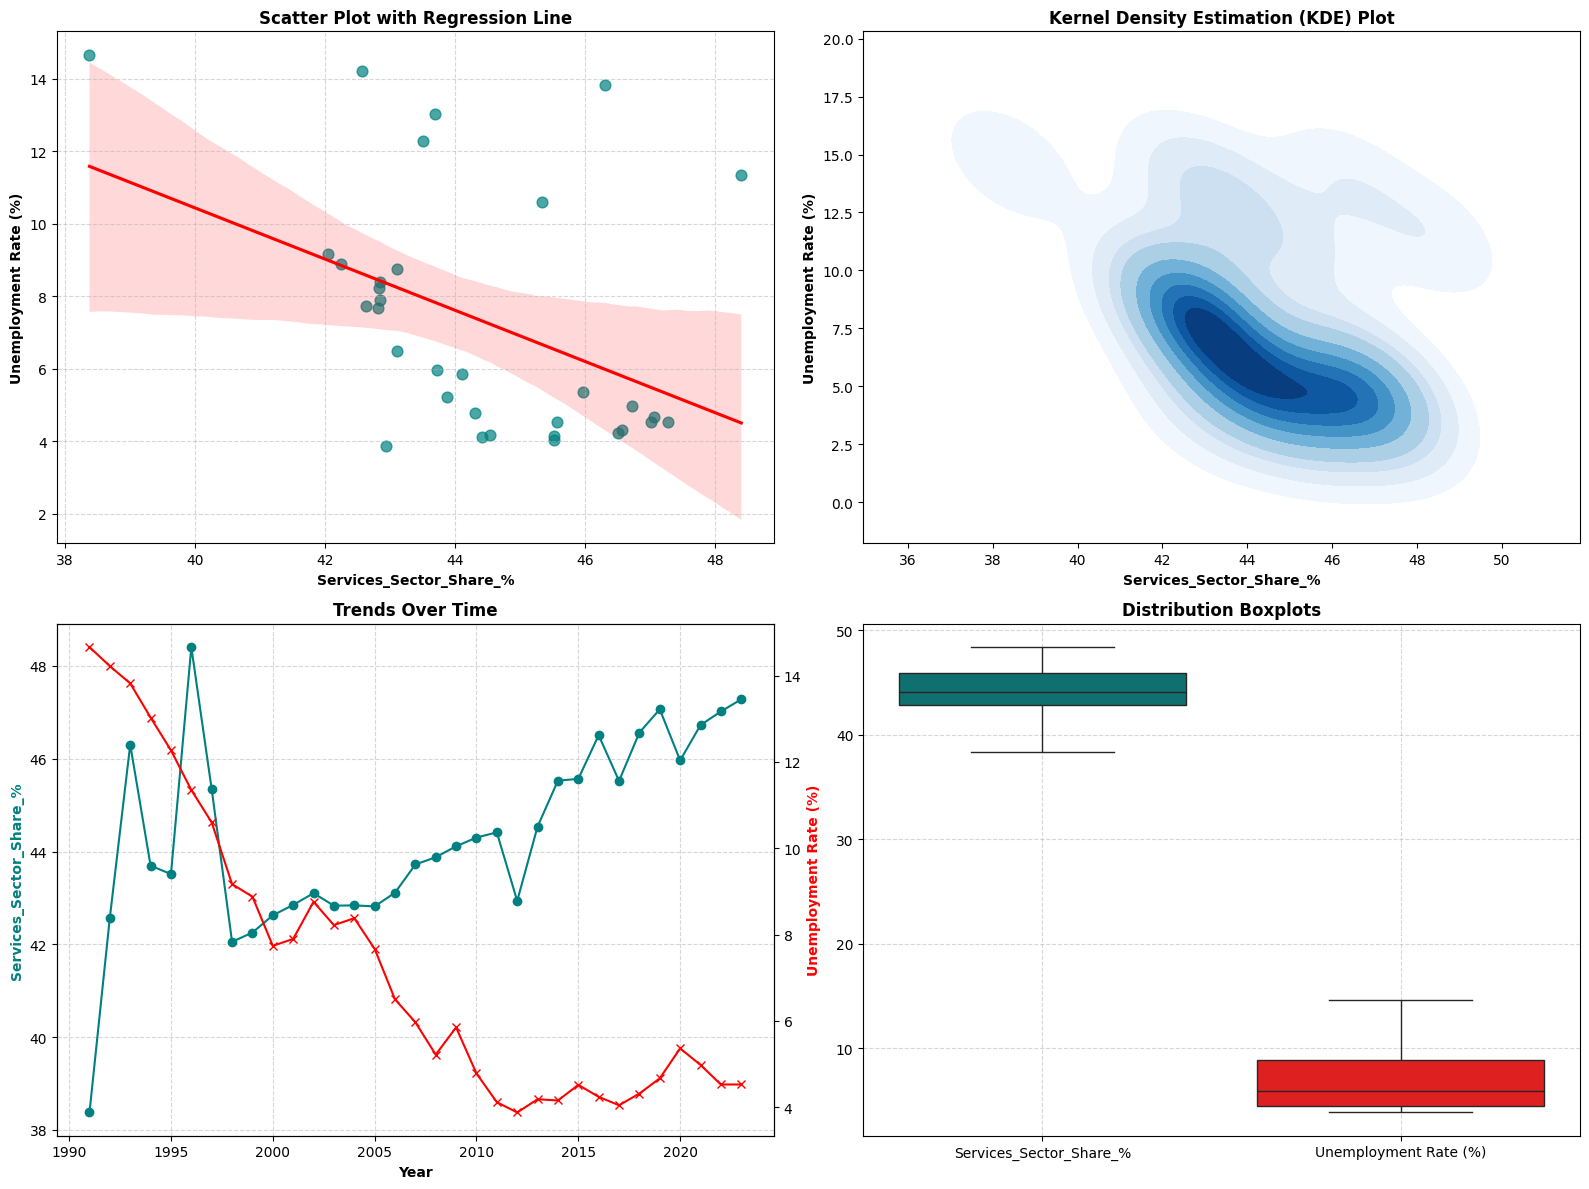

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter with Regression Line
sns.regplot(x=f_vals, y=u_vals, ax=axes[0, 0], scatter_kws={'alpha': 0.7, 's': 60}, line_kws={'color': 'red'}, color='teal')
axes[0, 0].set_xlabel('Services_Sector_Share_%', fontweight='bold')
axes[0, 0].set_ylabel('Unemployment Rate (%)', fontweight='bold')
axes[0, 0].set_title('Scatter Plot with Regression Line', fontweight='bold')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 2. KDE Density Plot
sns.kdeplot(x=f_vals, y=u_vals, cmap='Blues', fill=True, ax=axes[0, 1])
axes[0, 1].set_xlabel('Services_Sector_Share_%', fontweight='bold')
axes[0, 1].set_ylabel('Unemployment Rate (%)', fontweight='bold')
axes[0, 1].set_title('Kernel Density Estimation (KDE) Plot', fontweight='bold')

# 3. Dual Axis Time Series line plot
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
ax3.plot(combined_df.index.year, f_vals, color='teal', marker='o', label='Services_Sector_Share_%')
ax3_twin.plot(combined_df.index.year, u_vals, color='red', marker='x', label='Unemployment Rate (%)')
ax3.set_xlabel('Year', fontweight='bold')
ax3.set_ylabel('Services_Sector_Share_%', color='teal', fontweight='bold')
ax3_twin.set_ylabel('Unemployment Rate (%)', color='red', fontweight='bold')
ax3.set_title('Trends Over Time', fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.5)

# 4. Boxplot for distributions
sns.boxplot(data=[f_vals, u_vals], ax=axes[1, 1], palette=['teal', 'red'])
axes[1, 1].set_xticklabels(['Services_Sector_Share_%', 'Unemployment Rate (%)'])
axes[1, 1].set_title('Distribution Boxplots', fontweight='bold')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Advanced Models: Linear Regression & Residuals

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = f_vals.reshape(-1, 1)
y = u_vals

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

print("REGRESSION DIAGNOSTICS")
print(f"R-squared Score: {r2_score(y, y_pred):.4f}")
print(f"RMSE:            {np.sqrt(mean_squared_error(y, y_pred)):.4f}")
print(f"Coefficient:     {model.coef_[0]:.4f}")
print(f"Intercept:       {model.intercept_:.4f}")


REGRESSION DIAGNOSTICS
R-squared Score: 0.1827
RMSE:            3.0053
Coefficient:     -0.7054
Intercept:       38.6509


## 7. Lagged Analysis (Time Delays in Macro Effects)

In [23]:
print("LAG ANALYSIS: Macro-factors often take time to impact unemployment.")
print("=" * 70)

for lag in range(0, 5):
    shifted_feature = combined_df['Services_Sector_Share_%'].shift(lag)
    corr = combined_df['Unemployment_Rate'].corr(shifted_feature)
    print(f"Lag {lag} Years: correlation = {corr:.4f}")

print("\nThis identifies how many years it takes for changes in this sector to penetrate the labour market.")


LAG ANALYSIS: Macro-factors often take time to impact unemployment.
Lag 0 Years: correlation = -0.4275
Lag 1 Years: correlation = -0.4149
Lag 2 Years: correlation = -0.4129
Lag 3 Years: correlation = -0.4071
Lag 4 Years: correlation = -0.4012

This identifies how many years it takes for changes in this sector to penetrate the labour market.
